# Libraries

In [19]:
import torch 
from torch.utils.data import Dataset, random_split
from torch_geometric.loader import DataLoader
import numpy as np

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch_geometric.data import Data
from torch_geometric.nn import GINConv,global_add_pool
import os
import torch.nn as nn
import py3Dmol
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
#libraries of RDKIT
#-------------------------
from rdkit import Chem
from rdkit import RDConfig
from rdkit.Chem import rdmolops
from rdkit.Chem import AllChem
from rdkit.Chem import ChemicalFeatures
#-------------------------

from config import *
torch.manual_seed(RANDOM_SEED)

# Load custom Tox21 dataset
---
We have appended other 2 features linked to the toxicity dataset: **Molecular Weight (MW) and LogP(lipofily)**

***Note: we have considered also another feature called Global Toxicity 1/0 ***



In [4]:
tox21_df=pd.read_csv(DATASET_PATH)
print(f"Dataset caricato! Dimensioni: {tox21_df.shape}")



target_cols = [c for c in tox21_df.columns if c.startswith(('NR-', 'SR-'))]

#extraction of smiles,labels and global features
smiles=tox21_df["smiles"].values
global_features=tox21_df[["MW","LogP"]].values.astype(float)
labels=tox21_df[target_cols].values.astype(float)

print(f"- {len(smiles)} stringhe SMILES")
print(f"- Matrice Labels shape: {labels.shape}")
print(f"- Matrice Global Features shape: {global_features.shape}")
tox21_df.head()

Dataset caricato! Dimensioni: (7823, 15)
- 7823 stringhe SMILES
- Matrice Labels shape: (7823, 12)
- Matrice Global Features shape: (7823, 2)


,smiles,MW,LogP,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,258.324,1.34240,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,CCN1C(=O)NC(c2ccccc2)C1=O,204.229,1.29940,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
2,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,288.475,5.09030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,276.424,3.75244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
4,CC(O)(P(=O)(O)O)P(=O)(O)O,206.027,-0.99220,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Dataset class
---
## Extraction of features 
In our case we should manipulate molecule using a graph in which each node is an atom and each edge is a bond with another it.  
for each node we identify the following features otherwise it will be impossible to learn its chemical properties and structure:

- **Atom Type** (C, N, O, S, F, Cl, Br, I, P...) using One-Hot Encoding
- **Degree** (es. 1, 2, 3, 4).
- **Hybridization** (orbital geometry  ($sp, sp^2, sp^3$))
- **Aromatic** boolean values if atom belongs to the aromatic chain or not
- **Number of Hydrogens** (how many Hydrogens are attached )
- **Chirality** (if atom is chiral center R or S)
- **isDonor**  ( 1 or 0 Donates  electrons)
- **isAcceptor** (1 or 0 accepts electrons)
- **Formal Charge** (es. -1, 0, +1)




In [5]:
def one_hot_encoding(x,list_properties):
    # Se l'elemento 'x' non è nella lista consentita, usiamo l'ultimo elemento (spesso 'Unknown')
    if x not in list_properties:
        x = list_properties[-1]
    
    # Crea una lista: metti 1 se l'elemento corrisponde a x, altrimenti 0
    return [1 if s == x else 0 for s in list_properties]
    
class Dataset_tox21(Dataset):
    
    def __init__(self,smiles,labels,permitted_atoms,hybrization_type,degree_atoms,number_hydrogens):
        self.smiles=smiles
        self.labels=labels
        self.permitted_atoms=permitted_atoms
        self.hybrization_type=hybrization_type
        self.degree_atoms=degree_atoms
        self.number_hydrogens=number_hydrogens
        #definition Chemical rules for acceptor and donators
        self.fdefName = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
        self.factory = ChemicalFeatures.BuildFeatureFactory(self.fdefName)
        
        
        self.data_list = []
        
        # Process from SMILES->GRAPH
        for i in tqdm(range(len(smiles))):
            data = self.conversion_to_graph(smiles[i], labels[i])
            if data is not None:
                self.data_list.append(data)
        
    
    def get_atom_features(self,atom,donor_indices,acceptor_indices):
        
        atom_feature=[]
        # 1. Atom Type (One-Hot) 
        atom_feature += one_hot_encoding(atom.GetSymbol(),self.permitted_atoms)
        
        # 2 Atomic number(Scalar) ---
        # Lo scaliamo diviso 100 per mantenere i valori piccoli (tra 0 e 1 circa) per la rete neurale
        atom_feature += [atom.GetAtomicNum() * 0.01] 
        
        #
        # 3. atom degree
        atom_feature += one_hot_encoding(atom.GetDegree(),self.degree_atoms)
        
        #
        # 4. Hydrogens
        atom_feature += one_hot_encoding(atom.GetTotalNumHs(),self.number_hydrogens)
        
        # 5. Hybridization
        atom_feature += one_hot_encoding(atom.GetHybridization(), self.hybrization_type)
        
        # 6. Aromatic
        atom_feature += [1 if atom.GetIsAromatic() else 0]
        
        # 7 H-Bond Donor
        atom_idx = atom.GetIdx()
        atom_feature += [1 if atom_idx in donor_indices else 0]

        # 8 H-Bond Acceptor (Booleano) ---
        atom_feature += [1 if atom_idx in acceptor_indices else 0]
        
        # 9. Chirality (Tag R/S/None)
        try:
            chirality = atom.GetProp('_CIPCode')
            if chirality == 'R':
                atom_feature += [1, 0, 0] # R
            elif chirality == 'S':
                atom_feature += [0, 1, 0] # S
            else:
                atom_feature += [0, 0, 1] # None/Other
        except:
            atom_feature += [0, 0, 1] # Nessuna chiralità definita
        
        #formal charge (-2,-1,0,+1,+2)   
        formal_charge = atom.GetFormalCharge()
        charges_list = [-2, -1, 0, 1, 2]
        atom_feature += one_hot_encoding(formal_charge, charges_list)
        
        return torch.tensor(atom_feature, dtype=torch.float)
        
        
        
    def conversion_to_graph(self,smiles,labels): 
        
        #transformation from smile to graph representation
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        #Compute Donators and Acceptors
        feats = self.factory.GetFeaturesForMol(mol)
        donor_indices = []
        acceptor_indices = []
        
        for feat in feats:
            #selection of feats which belong to Donor or Acceptor
            if feat.GetFamily() == 'Donor':
                donor_indices.extend(feat.GetAtomIds())
            elif feat.GetFamily() == 'Acceptor':
                acceptor_indices.extend(feat.GetAtomIds())
            
        donor_indices = set(donor_indices)
        acceptor_indices = set(acceptor_indices)
        
        
        atom_features_list = []
        #Assing chirality
        Chem.AssignStereochemistry(mol)
        for atom in mol.GetAtoms():
            #obtain for each atom==node a set of features
            atom_features_list.append(self.get_atom_features(atom, donor_indices, acceptor_indices))
        
        #stack in x all features
        x = torch.stack(atom_features_list)
        
        #Computation of arcs 
        edge_indices = []
        for bond in mol.GetBonds():
            k = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            edge_indices += [[k, j], [j, k]]
    
        if len(edge_indices) == 0:
            edge_index = torch.empty((2, 0), dtype=torch.long)
        else:
            edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

        #labels 
        y_tensor = None
        if labels is not None:
            y_tensor = torch.tensor(labels, dtype=torch.float).view(1, -1)

        return Data(x=x, edge_index=edge_index, y=y_tensor)
    
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, i):
        return self.data_list[i]


# Dataloader 

In [6]:
full_dataset=Dataset_tox21(smiles=smiles,labels=labels,permitted_atoms=TYPE_ATOMS,hybrization_type=HYBRIDIZATION_TYPE,degree_atoms=ATOM_DEGREE,number_hydrogens=NUMBER_HYDROGENS)

dataset_size=len(full_dataset)
val_size = int(dataset_size * VAL_PERCENTAGE) 
test_size= int(dataset_size* TEST_PERCENTAGE)
train_size = dataset_size - val_size - test_size

print(f"Totale Molecole: {dataset_size}")
print(f"Training Set: {train_size}")
print(f"Test Set: {test_size}")

generator= torch.Generator().manual_seed(RANDOM_SEED)

#division randomically 
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size], 
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
print("train loader ok")
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)
print("val loader ok")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)
print("test loader ok")
for batch in train_loader:
    print(f"Batch scaricato: {batch}")
    print(f" - Batch x shape: {batch.x.shape}")     # [Num_Atomi_Totali_nel_batch, Features]
    print(f" - Batch y shape: {batch.y.shape}")     # [64, 12] -> Ecco le label per 64 molecole
    print(f" - Batch edge_index: {batch.edge_index.shape}")
    break 

  0%|          | 0/7823 [00:00<?, ?it/s]

[23:19:52] WARNING: not removing hydrogen atom without neighbors


Totale Molecole: 7823
Training Set: 5477
Test Set: 1173
train loader ok
val loader ok
test loader ok
Batch scaricato: DataBatch(x=[1410, 56], edge_index=[2, 2914], y=[64, 12], batch=[1410], ptr=[65])
 - Batch x shape: torch.Size([1410, 56])
 - Batch y shape: torch.Size([64, 12])
 - Batch edge_index: torch.Size([2, 2914])


# GNN Model
--- 

It is characterized by two models:
1) **GINMLP** 
2) **GNN**

In [7]:
class GINMLP(nn.Module):
    
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super(GINMLP, self).__init__()
    
        self.lin1 = nn.Linear(in_channels, out_channels)
        self.bn1 = nn.BatchNorm1d(out_channels)
        
        #
        self.lin2 = nn.Linear(out_channels, out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
      
        self.act = nn.SiLU() 
        self.dropout = nn.Dropout(dropout)
        
        # to appply a possible residual connection
        self.has_residual = (in_channels == out_channels)
        
    def forward(self, x):
        identity = x  # Salviamo l'input per la somma finale (Residual)
        
        # Block1
        out = self.lin1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.dropout(out)
        
        # Block 2
        out = self.lin2(out)
        out = self.bn2(out)
        out = self.act(out)
        
        # Residual Connection: x_new = F(x) + x
        if self.has_residual:
            return out + identity
        else:
            return out
        
#function which adapts input and output channels        
def gin_mlp(input_dim,output_dim):
    return GINMLP(input_dim,output_dim)

class Tox21GNN(nn.Module):
    
    def __init__(self,num_node_features,hidden_channels=64,num_classes=12):
        super(Tox21GNN, self).__init__()
        #Layer 1 GINCONV 
        self.conv1=GINConv(gin_mlp(num_node_features,hidden_channels))
        
        self.conv2=GINConv(gin_mlp(hidden_channels,hidden_channels))
        self.conv3=GINConv(gin_mlp(hidden_channels,hidden_channels))
        self.conv4=GINConv(gin_mlp(hidden_channels,hidden_channels))
        self.conv5=GINConv(gin_mlp(hidden_channels,hidden_channels))
        
        #Classifier head to obtain output of 12 classes
        self.classifier= nn.Sequential( 
            nn.Linear(hidden_channels,hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.SiLU(),
            nn.Dropout(p=0.3),
                                    
            nn.Linear(hidden_channels, hidden_channels // 2), 
            nn.BatchNorm1d(hidden_channels // 2),
            nn.SiLU(),                    # <--- Cambio Chiave
            nn.Dropout(p=0.2),
            nn.Linear(hidden_channels // 2, num_classes)
        )
        
    def forward(self,x,edge_index,batch):
        # Layer 1
        x = self.conv1(x, edge_index)
        
        # Layer 2
        x = self.conv2(x, edge_index)

        # Layer 3
        x = self.conv3(x, edge_index)
        
        # Layer 4
        x = self.conv4(x, edge_index)
        
        # Layer 5
        x = self.conv5(x, edge_index)
        
        #Global Pooling: prende tutti i vettori degli atomi che appartengono alla stessa molecola e
        # li somma insieme per creare un unico "Super-Vettore" che rappresenta l'intera molecola.
        x = global_add_pool(x, batch)  
        
        
        logits = self.classifier(x)
        
        return logits

#Creation Model
print(f"Usando device: {DEVICE}")        
model=Tox21GNN(num_node_features=NODE_FEATURES,hidden_channels=HIDDEN_CHANNELS,num_classes=NUM_CLASSES)

model = model.to(DEVICE)

print(model)        

Usando device: cuda
Tox21GNN(
  (conv1): GINConv(nn=GINMLP(
    (lin1): Linear(in_features=56, out_features=64, bias=True)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
    (dropout): Dropout(p=0.1, inplace=False)
  ))
  (conv2): GINConv(nn=GINMLP(
    (lin1): Linear(in_features=64, out_features=64, bias=True)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
    (dropout): Dropout(p=0.1, inplace=False)
  ))
  (conv3): GINConv(nn=GINMLP(
    (lin1): Linear(in_features=64, out_features=64, bias=True)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, 

# Train

# Compute weights to give a weighted loss wrt tO 12 classes of toxicities

In [8]:
def compute_class_weights(loader):
    print("Calcolo dei pesi per il bilanciamento classi (pos_weight)...")
    all_labels = []
    
   
    for batch in loader:
        all_labels.append(batch.y)
    
    
    all_labels = torch.cat(all_labels, dim=0).numpy()
    
    weights = []
    for i in range(12): # Per (colonna)
        col = all_labels[:, i]
    
        valid_indices = ~np.isnan(col)
        valid_labels = col[valid_indices]
        
        n_pos = np.sum(valid_labels == 1)
        n_neg = np.sum(valid_labels == 0)
        
        if n_pos > 0:
            weight = n_neg / n_pos
        else:
            weight = 1.0 # Fallback se non ci sono positivi (raro)
            
        weights.append(weight)
        
    return torch.tensor(weights, dtype=torch.float)


class_weights = compute_class_weights(train_loader)
print(f"Pesi calcolati: {class_weights}")


class_weights = class_weights.to(DEVICE)

Calcolo dei pesi per il bilanciamento classi (pos_weight)...
Pesi calcolati: tensor([22.0045, 27.6970,  7.5139, 18.8204,  6.7639, 17.9650, 29.9384,  4.9414,
        24.3897, 16.0682,  5.4214, 14.7774])


# Configuration

In [9]:
def create_lr_scheduler(optimizer, num_train_steps, warmup_steps):
    """Creates a learning rate scheduler with a linear warmup and cosine decay."""
    
    # Scheduler for the linear warmup phase
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps
    )
    
    # Scheduler for the cosine decay phase
    decay_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=(num_train_steps - warmup_steps)
    )
    
    # Chain them together
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, decay_scheduler],
        milestones=[warmup_steps]
    )
    return lr_scheduler

In [10]:
steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = int(total_steps * 0.20) # 10% del tempo speso in warmup

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights, reduction='none')
scheduler = create_lr_scheduler(optimizer, total_steps, warmup_steps)

In [11]:
def apply_masks(batch,out):
    
    y = batch.y
    #Gestione dei NaN (La Maschera)
        
    # Creiamo una maschera booleana: True se è un numero, False se è NaN
    is_labeled = ~torch.isnan(y)
    y = torch.nan_to_num(y, nan=0.0)
        
    loss_matrix = criterion(out, y)
        
    # 4. Applicazione Maschera
    # Azzeriamo la loss dove il dato originale era NaN
    valid_loss = loss_matrix * is_labeled.float()
    return valid_loss,is_labeled

In [12]:
def train_one_epoch():
    model.train()
    total_loss = 0
    total_molecules = 0
    progress_bar = tqdm(train_loader, desc="Training")
    for batch in progress_bar:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        
        
        valid_loss,is_labeled=apply_masks(batch,out)
        loss = valid_loss.sum() / is_labeled.sum()
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item() * batch.num_graphs # Per media pesata corretta
        total_molecules += batch.num_graphs
        
    return total_loss / total_molecules

# Validation step

In [13]:
def run_validation_epoch():
    
    model.eval()
    running_loss = 0.0
    total_molecules = 0
    with torch.no_grad():
        for batch in val_loader:
            batch=batch = batch.to(DEVICE)
            
            out=model(batch.x, batch.edge_index, batch.batch)
            loss,is_labeled=apply_masks(batch,out)
            
            loss = loss.sum() / is_labeled.sum()
            running_loss += loss.item() * batch.num_graphs
            total_molecules += batch.num_graphs
            
    average_loss = running_loss / total_molecules
    return average_loss

In [14]:
print("Start Training")
for epoch in range(EPOCHS):
    train_loss=train_one_epoch()
    val_loss = run_validation_epoch()
    print(f"Epoch {epoch + 1}/{EPOCHS} | Training Loss: {train_loss:.6f} | Validation Loss: {val_loss:.6f}")

Start Training


Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 1/200 | Training Loss: 1.324625 | Validation Loss: 1.256171


Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 2/200 | Training Loss: 1.294952 | Validation Loss: 1.222262


...

Epoch 198/200 | Training Loss: 0.603586 | Validation Loss: 0.960673


Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 199/200 | Training Loss: 0.608836 | Validation Loss: 0.977739


Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch 200/200 | Training Loss: 0.609800 | Validation Loss: 0.975665


# Test


In [15]:
def get_predictions(model,device):
    model.eval()
    all_probs = []
    all_targets = []
    
    print("Generazione previsioni sul Test Set...")
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            batch = batch.to(device)
            
            # 1. Forward Pass
            logits = model(batch.x, batch.edge_index, batch.batch)
            
            # 2. Applicazione Sigmoide (Logits -> Probabilità 0-1)
            probs = torch.sigmoid(logits)
            
            # 3. Spostiamo su CPU e salviamo
            all_probs.append(probs.cpu())
            all_targets.append(batch.y.cpu())
            
    # Concateniamo tutto in due grandi matrici
    y_probs = torch.cat(all_probs, dim=0).numpy()
    y_true = torch.cat(all_targets, dim=0).numpy()
    
    return y_probs, y_true


y_probs, y_true = get_predictions(model,DEVICE)
print(f"Shape Previsioni: {y_probs.shape}")

Generazione previsioni sul Test Set...


Testing:   0%|          | 0/19 [00:00<?, ?it/s]

Shape Previsioni: (1173, 12)


In [16]:


# Nomi dei 12 target di Tox21 (nell'ordine corretto del dataset)
task_names = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

roc_auc_scores = []
print("\n" + "="*50)
print(f"{'TASK NAME':<20} | {'ROC-AUC':<10} | {'Etichette Valide'}")
print("="*50)

for i, name in enumerate(task_names):
    # Estraiamo la colonna i-esima
    col_true = y_true[:, i]
    col_pred = y_probs[:, i]
    
    # MASCHERA PER I NaN
    # Prendiamo solo gli indici dove abbiamo una etichetta reale
    mask = ~np.isnan(col_true)
    valid_true = col_true[mask]
    valid_pred = col_pred[mask]
    
    # Controllo di sicurezza: Servono almeno una classe positiva e una negativa
    # altrimenti ROC-AUC crasha
    if len(np.unique(valid_true)) < 2:
        print(f"{name:<20} | {'N/A':<10} | {len(valid_true)} (Solo una classe)")
        continue
        
    # Calcolo Score
    score = roc_auc_score(valid_true, valid_pred)
    roc_auc_scores.append(score)
    
    print(f"{name:<20} | {score:.4f}     | {len(valid_true)}")

print("-" * 50)
print(f"MEDIA TOTALE ROC-AUC: {np.mean(roc_auc_scores):.4f}")
print("=" * 50)


TASK NAME            | ROC-AUC    | Etichette Valide
NR-AR                | 0.8253     | 1087
NR-AR-LBD            | 0.8872     | 1006
NR-AhR               | 0.8804     | 979
NR-Aromatase         | 0.8705     | 885
NR-ER                | 0.7057     | 927
NR-ER-LBD            | 0.8534     | 1041
NR-PPAR-gamma        | 0.8316     | 963
SR-ARE               | 0.8260     | 878
SR-ATAD5             | 0.9148     | 1058
SR-HSE               | 0.9097     | 976
SR-MMP               | 0.9238     | 875
SR-p53               | 0.8250     | 1013
--------------------------------------------------
MEDIA TOTALE ROC-AUC: 0.8544


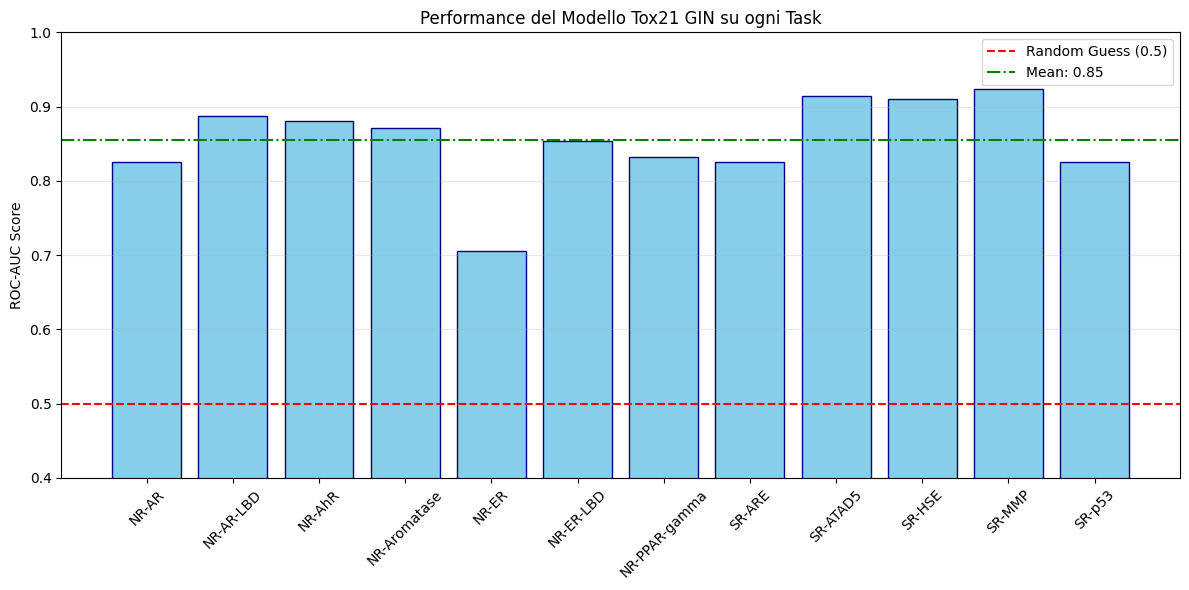

In [17]:
plt.figure(figsize=(12, 6))
plt.bar(task_names, roc_auc_scores, color='skyblue', edgecolor='navy')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random Guess (0.5)')
plt.axhline(y=np.mean(roc_auc_scores), color='g', linestyle='-.', label=f'Mean: {np.mean(roc_auc_scores):.2f}')

plt.ylim(0.4, 1.0) # ROC-AUC va da 0.5 a 1.0 (sotto 0.5 il modello è rotto)
plt.ylabel('ROC-AUC Score')
plt.title('Performance del Modello Tox21 GIN su ogni Task')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()